In [1]:
%load_ext autoreload
%autoreload 2

In [30]:
import numpy as np
import pandana as pdna
import geopandas as gpd
import pandas as pd
import osmnx as ox
import math
import networkx as nx
import sys
import matplotlib.pyplot as plt
# adding functions 
sys.path.insert(0, 'C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Walkability\\Other Cities\\Open-Walk-Index')
from walkability_functions import *

Choose a projected CRS to be used for all distance calculations.

In [4]:
folder = "C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Walkability\\Other Cities\\Colouring data & results\\"
proj_crs = "EPSG:7856"

Get a polygon of the place from OpenStreetMap. Alternatively, upload a place_gdf of your choice.

In [6]:
place = 'Sutherland Shire, Australia'
place_gdf = ox.geocode_to_gdf(place).to_crs(proj_crs)

<AxesSubplot: >

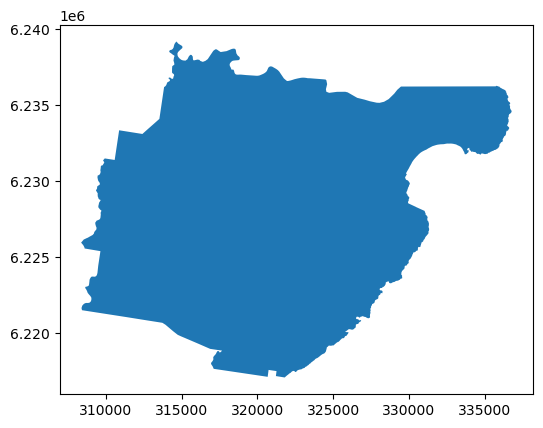

In [7]:
# check that we have the right place
place_gdf.geometry.plot()

## Import Data

Data sources:
1. OSM POIs
5. Employment data - in Australia this is based on open data from the Census, processed using the Employment Points notebook also available.

In [8]:
poi_dictionary = {
    'employment':{
        'category':['employment']
    },
    'shopping':{
        'shop':['bakery', 'clothes', 'supermarket', 'mall', 'greengrocer',
                'seafood', 'wine', 'butcher','convenience',
                'beverages', 'alcohol', 'bicycle_shop', 'department_store', 
                'doityourself', 'beauty_shop', 'outdoor_shop', 
                'stationery', 'bookshop', 'gift_shop', 'newsagent', 
                'car_dealership', 'furniture_shop', 'sports_shop',
                'garden_centre', 'computer_shop', 'shoe_shop', 'florist', 
                'video_shop', 'toy_shop', 'mobile_phone_shop', 'jeweller'],
        # possibly we could pick up all shop=True excluding a few. but not sure how
        # and many options to exclude
        'amenity':['marketplace'],
        'building':['kiosk', 'supermarket',],
    },
    'errands':{
        'amenity':['atm','bank','courthouse','post_box', 'post_office',
                   'clinic', 'dentist', 'doctors', 'hospital',
                   'pharmacy', 'veterinary', 'travel_agent',
                   'place_of_worship'],
        'shop':['optician', 'hairdresser', 'laundry',],
        'healthcare':['physiotherapist'],
        'office':['government'], #### further refine ?
    },
    'recreation':{
        'leisure':['dog_park', 'ice_rink', 'park', 'pitch', 'playground',
                   "fitness_centre","sports_centre", 'stadium', 'swimming_pool',
                   'swimming_area', 'track', 'water_park','golf_course',],
        'club':['social'],
        'amenity':['bar', 'biergarten', 'cafe', 'fast_food', 'food_court',
                   'ice_cream', 'pub', 'restaurant', 'nightclub',
                   'library', 'arts_centre', 'cinema', 'community_centre',
                   'social_centre', 'theatre',],
        'building':['stadium', 'castle', 'ruins',],
        'tourism':['aquarium', 'artwork', 'attraction', 'gallery',
                   'museum', 'picnic_site', 'theme_park', 'viewpoint',
                   'zoo'],
        'natural':['beach'],
    },
    'education':{
        'amenity':['college', 'kindergarten', 'music_school',
                   'school', 'university', 'childcare'],
    }
}

In [12]:
%%capture --no-stdout  
#hides deprecation warning related to Shapely and osmnx. turn off if something is not working.
osm_pois = poi_downloader(place_gdf, poi_dictionary, proj_crs)

In [10]:
employment_centrs = gpd.read_file((folder + 
                        "Sydney Data\\Data\\Centroids employment MBs.gpkg")).to_crs(proj_crs)

employment_centrs['category'] = 'employment'
employment_centrs['geometry'] = employment_centrs.geometry.centroid

In [56]:
employment_centrs.Jobs_count.max()

6975.782

Need to remove potential overlap between different data sources (and inside some data sources). For now I'm not worrying about this when using only OSM data. Then take this combined POI set and clip it to the study area: should be the same area as is covered by the network. This is important otherwise points outside the network may be erroneously linked to the network.

In [13]:
pois = pd.concat([osm_pois, employment_centrs])

pois = gpd.clip(pois, place_gdf.to_crs(proj_crs))

c:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\array.py:1406: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as GDA2020 / MGA zone 56 (the single non-null crs provided).
  warnings.warn(


### Categorise and weight POIs

Choose walk index weightings, and output the sums of each category and the total to check. The walk index will be out of 100 regardless of this sum, but it is important to note that eg. shopping is only '10% of the walk index' if shopping is 10 out of 100.

In [14]:
poi_parameters = pd.read_csv((folder + 
                              "Shared Aus Data\\poi_parameters_5.csv"),
                            index_col=0)

In [15]:
poi_weights = poi_parameters['weight'].copy()

poi_lambdas = poi_parameters['diminishing_returns_constant'].copy()

poi_variables = poi_parameters['variable'].copy()

poi_nums = poi_parameters['num_pois'].copy()

poi_gammas = poi_parameters['distance_constant'].copy()

In [16]:
print("total: ", sum(poi_weights))

total:  100.00000000000001


In [17]:
# change this to match the column containing job counts in your employment dataframe
poi_variables.loc['employment'] = 'Jobs_count'
# change this to make employment score more accurate (higher number) or to reduce index calculation time (low number)
poi_nums.loc['employment'] = 1200

# 1. Walking

## Pandana network creation.

Pandana expects edges to have a two item index based on the same IDs as the node index. (with thanks to https://github.com/shriv/accessibility-series/blob/master/Accounting%20for%20hills%20in%20accessibility%20analyses.ipynb)

In [18]:
#G = ox.graph_from_place(place, network_type='walk')
G = ox.graph.graph_from_polygon(place_gdf.to_crs('EPSG:4326').geometry[0], network_type='walk')

In [19]:
# Get nodes and edges as geodataframes (gdfs) from OSMNX network
graph_df = ox.graph_to_gdfs(G)
nodes_gdfs = graph_df[0].to_crs(proj_crs)
edges_gdfs = graph_df[1].to_crs(proj_crs)

In [20]:
# with new OSMnx graph from polygon seems to be different
edges_gdfs = edges_gdfs.reset_index()
# Setting indices of Edges gdfs to match expected dataframe for Pandana
edges_gdfs['from_idx'] = edges_gdfs['u']
edges_gdfs['to_idx'] = edges_gdfs['v']
edges_gdfs= edges_gdfs.set_index(['from_idx', 'to_idx'])
edges_gdfs.index.names= ['','']

# Setting indices of Nodes gdfs to match expected dataframe for Pandana
nodes_gdfs.index.name = 'id'

In [21]:
# Create a pandana network with data extracted from an OSMNX graph
distance_network = pdna.Network(nodes_gdfs.geometry.x, nodes_gdfs.geometry.y,
                                   edges_gdfs['u'], edges_gdfs['v'], 
                                   edges_gdfs[['length']])

### Pandana network querying. 

In [22]:
maximum_dist=2400

In [44]:
%%capture --no-stdout 
#hides FutureWarning related to Pandana. turn off if something is not working.
results_walk = there_index(distance_network, pois, poi_dictionary, poi_weights, poi_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=maximum_dist)

Finished category: employment
Maximum score: 2.9017962157142954 out of 31.9
Finished category: education
Maximum score: 7.543028231667891 out of 14.3
Finished category: shopping
Maximum score: 15.8631905474988 out of 21.6
Finished category: errands
Maximum score: 6.505446636429708 out of 8.9
Finished category: recreation
Maximum score: 17.151882502554255 out of 23.3


In [45]:
# base index - no clustering
max(results_walk['THERE_Index']), np.mean(results_walk['THERE_Index'])

(45.401687255974856, 21.547123342959686)

In [31]:
%%capture --no-stdout 
#hides FutureWarning related to Pandana. turn off if something is not working.
results_walk_10 = cluster_index(distance_network, pois, poi_dictionary, poi_weights, poi_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=maximum_dist, loop=10)                        

Finished category: employment
Maximum score: 2.9017962157142954 out of 31.9
Finished category: education
Maximum score: 7.543028231667891 out of 14.3
Finished category: shopping
Maximum score: 15.8631905474988 out of 21.6
Finished category: errands
Maximum score: 6.505446636429708 out of 8.9
Finished category: recreation
Maximum score: 17.151882502554255 out of 23.3
Finished category: employment
Maximum score: 2.3000112517774927 out of 31.9
Finished category: education
Maximum score: 5.996547277112264 out of 14.3
Finished category: shopping
Maximum score: 12.923148693269642 out of 21.6
Finished category: errands
Maximum score: 5.300969314267268 out of 8.9
Finished category: recreation
Maximum score: 13.976083633134147 out of 23.3
Finished category: employment
Maximum score: 2.2260834736225807 out of 31.9
Finished category: education
Maximum score: 5.8026319511255675 out of 14.3
Finished category: shopping
Maximum score: 12.478053166121777 out of 21.6
Finished category: errands
Maximum 

In [32]:
max(results_walk_10['THERE_Index']), np.mean(results_walk_10['THERE_Index'])  

(35.39154231226759, 16.022365764825704)

In [33]:
%%capture --no-stdout 
#hides FutureWarning related to Pandana. turn off if something is not working.
results_walk_25 = cluster_index(distance_network, pois, poi_dictionary, poi_weights, poi_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=maximum_dist, loop=25)                        

Finished category: employment
Maximum score: 2.9017962157142954 out of 31.9
Finished category: education
Maximum score: 7.543028231667891 out of 14.3
Finished category: shopping
Maximum score: 15.8631905474988 out of 21.6
Finished category: errands
Maximum score: 6.505446636429708 out of 8.9
Finished category: recreation
Maximum score: 17.151882502554255 out of 23.3
Finished category: employment
Maximum score: 2.3000112517774927 out of 31.9
Finished category: education
Maximum score: 5.996547277112264 out of 14.3
Finished category: shopping
Maximum score: 12.923148693269642 out of 21.6
Finished category: errands
Maximum score: 5.300969314267268 out of 8.9
Finished category: recreation
Maximum score: 13.976083633134147 out of 23.3
Finished category: employment
Maximum score: 2.2260834736225807 out of 31.9
Finished category: education
Maximum score: 5.8026319511255675 out of 14.3
Finished category: shopping
Maximum score: 12.478053166121777 out of 21.6
Finished category: errands
Maximum 

In [34]:
max(results_walk_25['THERE_Index']), np.mean(results_walk_25['THERE_Index'])  

(35.39154207803832, 16.02236572815714)

In [37]:
gdf_walk_25 = gpd.GeoDataFrame(result_rounding(results_walk_25), geometry = gpd.GeoSeries.from_xy(results_walk_25.x, results_walk_25.y, crs=proj_crs))

In [46]:
gdf_walk_base = gpd.GeoDataFrame(result_rounding(results_walk), geometry = gpd.GeoSeries.from_xy(results_walk.x, results_walk.y, crs=proj_crs))

(array([415.,  71., 114.,  57.,  50.,  43.,  41.,  49.,  38.,  57.,  58.,
         68.,  61.,  55.,  79.,  62.,  53.,  78.,  69.,  97.,  99., 103.,
        134., 106., 122., 147., 175., 158., 223., 188., 187., 195., 225.,
        250., 178., 218., 195., 205., 235., 216., 221., 223., 234., 237.,
        238., 226., 236., 263., 250., 259., 286., 275., 230., 246., 272.,
        242., 230., 165., 179., 185., 194., 219., 184., 159., 166., 158.,
        162., 131., 117., 139.,  90., 118., 150., 137., 148., 139., 121.,
        103.,  94.,  63.,  76.,  58.,  66.,  54.,  53.,  74.,  91.,  80.,
         75.,  80.,  82.,  93.,  78.,  61.,  67.,  54.,  33.,  39.,  11.,
          9.]),
 array([ 0.     ,  0.45402,  0.90804,  1.36206,  1.81608,  2.2701 ,
         2.72412,  3.17814,  3.63216,  4.08618,  4.5402 ,  4.99422,
         5.44824,  5.90226,  6.35628,  6.8103 ,  7.26432,  7.71834,
         8.17236,  8.62638,  9.0804 ,  9.53442,  9.98844, 10.44246,
        10.89648, 11.3505 , 11.80452, 12.25854

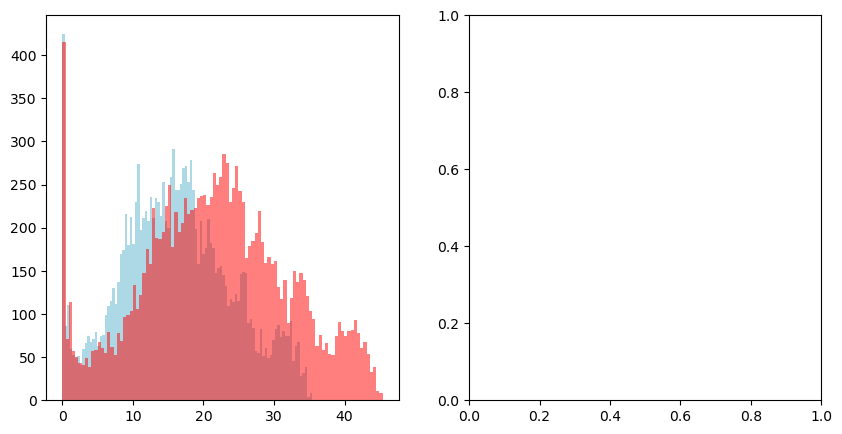

In [53]:
#plot histogram of THERE index
fig, ax = plt.subplots(1,2, figsize=(10, 5))
ax[0].hist(gdf_walk_25['THERE_Index'], bins=100, color='lightblue')
ax[0].hist(gdf_walk_base['THERE_Index'], bins=100, color='red',alpha=0.5)

(<AxesSubplot: >, <AxesSubplot: >)

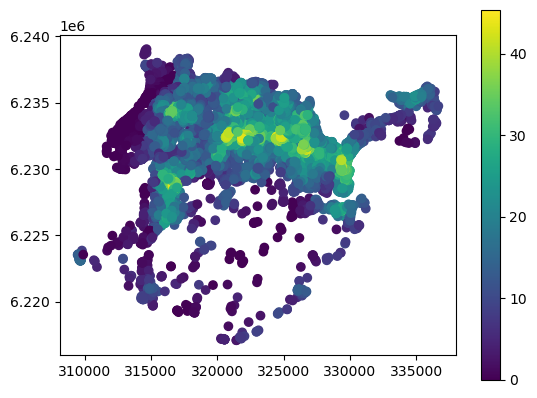

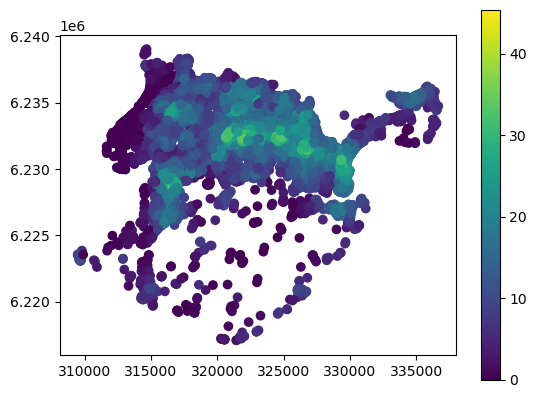

In [48]:
gdf_walk_base.plot('THERE_Index', legend=True, vmax=gdf_walk_base.THERE_Index.max()), gdf_walk_25.plot('THERE_Index', legend=True, vmax=gdf_walk_base.THERE_Index.max())

In [28]:
%%capture --no-stdout 
#hides FutureWarning related to Pandana. turn off if something is not working.
results_walk = cluster_index(distance_network, pois, poi_dictionary, poi_weights, poi_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=maximum_dist, loop=2, chain_frac = 0.5)
max(results_walk_0.5['THERE_Index']), np.mean(results_walk['THERE_Index'])                          

0.5
Finished category: employment
Maximum score: 2.9017962157142954 out of 31.9
Finished category: education
Maximum score: 7.543028231667891 out of 14.3
Finished category: shopping
Maximum score: 15.8631905474988 out of 21.6
Finished category: errands
Maximum score: 6.505446636429708 out of 8.9
Finished category: recreation
Maximum score: 17.151882502554255 out of 23.3
Finished category: employment
Maximum score: 1.9991187698090924 out of 31.9
Finished category: education
Maximum score: 5.2271763157561395 out of 14.3
Finished category: shopping
Maximum score: 11.453127766155067 out of 21.6
Finished category: errands
Maximum score: 4.698730653186047 out of 8.9
Finished category: recreation
Maximum score: 12.388184198424089 out of 23.3


In [29]:
max(results_walk_0.5['THERE_Index']), np.mean(results_walk_0.5['THERE_Index'])    

(32.58029951994439, 14.074810929628475)

## Time tests

In [90]:
# change this to match the column containing job counts in your employment dataframe
poi_variables.loc['employment'] = 'Jobs_count'
# change this to make employment score more accurate (higher number) or to reduce index calculation time (low number)
poi_nums.loc['employment'] = 1200

In [91]:
# time testing using just employment
category = 'employment'
distance = maximum_dist
return_no=5

dim_const = poi_lambdas[category]
dist_const = poi_gammas[category]
num_pois = poi_nums[category]
weight = poi_weights[category]
cat_name = ''.join((str(category),"_",str(weight)))

dim_opp_weight = [(1-np.exp(-dim_const*x)) - (1-np.exp(-dim_const*(x-1))) for x in range(1,num_pois+1)]

results = distance_network.nodes_df.copy()

total_weight = sum(poi_weights)

In [95]:
%%timeit -n 1 -r 3
%%capture --no-stdout
relevant_pois = gpd.GeoDataFrame()
for key in poi_dictionary[category]:
    if key in pois:
        relevant_pois = pd.concat([relevant_pois, pois.loc[(pois[key].isin(poi_dictionary[category][key]))]])

relevant_pois = relevant_pois.set_index(poi_variables[category])
                
x, y = (relevant_pois['geometry'].x, relevant_pois['geometry'].y)

distance_network.set_pois(category, distance, num_pois, x, y)

559 ms ± 148 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)


In [125]:
%%timeit -n 1 -r 3
%%capture --no-stdout
relevant_pois = gpd.GeoDataFrame()
for key in poi_dictionary[category]:
    if key in pois:
        relevant_pois = pd.concat([relevant_pois, pois.loc[(pois[key].isin(poi_dictionary[category][key]))]])

relevant_pois = relevant_pois.set_index(poi_variables[category])
                
x, y = (relevant_pois['geometry'].x, relevant_pois['geometry'].y)

distance_network.set_pois(category, distance, num_pois, x, y)

access_2 = distance_network.nearest_pois(
    distance=distance, category=category, num_pois=num_pois, include_poi_ids=True)

accesssum = access_2.sum(axis=1)

12min 49s ± 22.8 s per loop (mean ± std. dev. of 3 runs, 1 loop each)


In [124]:
%%timeit -n 1 -r 3
%%capture --no-stdout
relevant_pois = gpd.GeoDataFrame()
for key in poi_dictionary[category]:
    if key in pois:
        relevant_pois = pd.concat([relevant_pois, pois.loc[(pois[key].isin(poi_dictionary[category][key]))]])

relevant_pois = relevant_pois.set_index(poi_variables[category])
                
x, y = (relevant_pois['geometry'].x, relevant_pois['geometry'].y)

#distance_network.set_pois(category, distance, num_pois, x, y)
poi_nodes = distance_network.get_node_ids(x, y, distance)
distance_network.set(poi_nodes, variable=poi_nodes.index, name=category)

access = distance_network.aggregate(
    distance=distance, type="sum", decay="flat", name=category)

13.4 s ± 158 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)


In [93]:
%%timeit -n 1 -r 3
%%capture --no-stdout
# this is the new way

impedance = np.exp(-0.001*access.iloc[:,0:num_pois])
impedance[access.iloc[:,0:num_pois] == 2400] = 0

attractiveness = np.nan_to_num(access.iloc[:,num_pois:2*num_pois].values, nan=0.0)
attractiveness_sum = attractiveness.cumsum(axis=1).astype(np.int64)

max_opps = np.max(attractiveness_sum)
dim = [(1-np.exp(-dim_const*(x+1))) - (1-np.exp(-dim_const*x)) for x in range(max_opps+1)]

results[poi_variables[category]] = (np.array(dim)[attractiveness_sum]*attractiveness*impedance).sum(axis=1)

results[cat_name] = weight*results[poi_variables[category]]

36.9 s ± 4.56 s per loop (mean ± std. dev. of 3 runs, 1 loop each)


In [94]:
%%timeit -n 1 -r 3
%%capture --no-stdout
# this is the new way

impedance = (access.iloc[:,0:num_pois].applymap(access_weight, distance=distance,beta=dist_const))
attractiveness = np.nan_to_num(access.iloc[:,num_pois:2*num_pois].values, nan=0.0)
attractiveness_sum = attractiveness.cumsum(axis=1).astype(np.int64)

max_opps = np.max(attractiveness_sum)
dim = np.array([(1-np.exp(-dim_const*(x+1))) - (1-np.exp(-dim_const*x)) for x in range(max_opps+1)])

results[poi_variables[category]] = (np.array(dim)[attractiveness_sum]*attractiveness*impedance).sum(axis=1)

results[cat_name] = weight*results[poi_variables[category]]

3min 8s ± 9.74 s per loop (mean ± std. dev. of 3 runs, 1 loop each)


In [85]:
%%timeit -n 1 -r 3
%%capture --no-stdout
# alternative new way

#impedance = (access.iloc[:,0:num_pois].applymap(access_weight, distance=distance,beta=dist_const))
#attractiveness = np.nan_to_num(access.iloc[:,num_pois:2*num_pois].values, nan=0.0)
#attractiveness_sum = attractiveness.cumsum(axis=1).astype(np.int64)

dim_2 = [(1-np.exp(-dim_const*(x+1))) - (1-np.exp(-dim_const*x)) for x in attractiveness_sum]

#results[poi_variables[category]] = (dim_2*attractiveness*impedance).sum(axis=1)

#results[cat_name] = weight*results[poi_variables[category]]

3.93 s ± 38 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)


In [89]:
%%timeit -n 1 -r 3
%%capture --no-stdout

results[poi_variables[category]] = (dim[attractiveness_sum]*attractiveness*impedance).sum(axis=1)

814 ms ± 31.7 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)


In [87]:
%%timeit -n 1 -r 3
%%capture --no-stdout

results[poi_variables[category]] = (dim_2*attractiveness*impedance).sum(axis=1)

1.33 s ± 27.9 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)


## Cycling

## Pandana network creation.

Pandana expects edges to have a two item index based on the same IDs as the node index. (with thanks to https://github.com/shriv/accessibility-series/blob/master/Accounting%20for%20hills%20in%20accessibility%20analyses.ipynb)

In [14]:
#G = ox.graph_from_place(place, network_type='walk')
G = ox.graph.graph_from_polygon(place_gdf.to_crs('EPSG:4326').geometry[0], network_type='walk')

In [15]:
# Get nodes and edges as geodataframes (gdfs) from OSMNX network
graph_df = ox.graph_to_gdfs(G)
nodes_gdfs = graph_df[0].to_crs(proj_crs)
edges_gdfs = graph_df[1].to_crs(proj_crs)

In [17]:
# with new OSMnx graph from polygon seems to be different
edges_gdfs = edges_gdfs.reset_index()
# Setting indices of Edges gdfs to match expected dataframe for Pandana
edges_gdfs['from_idx'] = edges_gdfs['u']
edges_gdfs['to_idx'] = edges_gdfs['v']
edges_gdfs= edges_gdfs.set_index(['from_idx', 'to_idx'])
edges_gdfs.index.names= ['','']

# Setting indices of Nodes gdfs to match expected dataframe for Pandana
nodes_gdfs.index.name = 'id'
# Create a pandana network with data extracted from an OSMNX graph
distance_network = pdna.Network(nodes_gdfs.geometry.x, nodes_gdfs.geometry.y,
                                   edges_gdfs['u'], edges_gdfs['v'], 
                                   edges_gdfs[['length']])

### Pandana network querying. 

In [18]:
maximum_dist=2400

In [24]:
%%capture --no-stdout 
#hides FutureWarning related to Pandana. turn off if something is not working.
results_walk = there_index(distance_network, pois, poi_dictionary, poi_weights, poi_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=maximum_dist)

Finished category: employment
Maximum score: 16.74194251520912 out of 31.9
Finished category: education
Maximum score: 12.154540870540512 out of 14.3
Finished category: shopping
Maximum score: 21.58805337760481 out of 21.6
Finished category: errands
Maximum score: 8.859800954807657 out of 8.9
Finished category: recreation
Maximum score: 23.287113134175556 out of 23.3


In [25]:
# sanity check
max(results_walk['THERE_Index']), np.mean(results_walk['THERE_Index'])

(75.35145047019033, 31.352679869207535)

## Export results

Reduce the number of decimal places before export, distances do not need to be below 1m.

In [36]:
def result_rounding(results):
    # reduces results size for export
    # score columns such as THERE_Index, employment_subtotal etc -> 3 decimal places
    # distance columns such as employment1 -> 0 decimal places (nearest metre)
    # avoid doing anything to connect_id, x or y
    rounding_dict = {**{k:3 for k in results.columns if "Index" in k or "." in k
                        and 'connect_id' not in k},
                     **{k:0 for k in results.columns if "Index" not in k and "." not in k
                        and k != 'x'
                        and k != 'y'}}
    return results.round(rounding_dict)

In [25]:
small_w_results = gpd.GeoDataFrame(result_rounding(results_walk), geometry = gpd.GeoSeries.from_xy(results_walk.x, results_walk.y, crs=proj_crs))

 ### Population weighted results

Import smallest statistical unit for which population data is available (meshblocks in Australia). Join this to the results (by population weighted centroid location if available, otherwise geometric centroid location). Then results can be graphed or visualised by population, giving a more accurate picture of the population access by walking.

In [26]:
meshblocks = gpd.read_file(folder + "Sydney Data\\Data\\2016_NSW_MBs\\MB_2016_NSW.shp").to_crs(proj_crs)
meshblocks['MB_CODE16'] = meshblocks['MB_CODE16'].astype('int64')
meshblocks.geometry = meshblocks.centroid

In [27]:
population = pd.read_csv(folder + "Sydney Data\\Data\\2016_NSW_MBs\\2016 census mesh block counts.csv")
population = population.set_index('MB_CODE_2016')

In [28]:
meshblocks = meshblocks.join(population, on='MB_CODE16', how='left')

In [29]:
meshblocks_w = nearest_to_centroids(meshblocks, small_w_results, how='left', rsuffix = 'walk', max_distance=500)
meshblocks_w = meshblocks_w.clip(place_gdf)

Population weighted average THERE index:

In [30]:
valid_mbs = meshblocks_w[~meshblocks_w['THERE_Index'].isna()]

In [31]:
sum(valid_mbs['Person']*valid_mbs['THERE_Index'])/sum(valid_mbs['Person'])

32.26707814388774

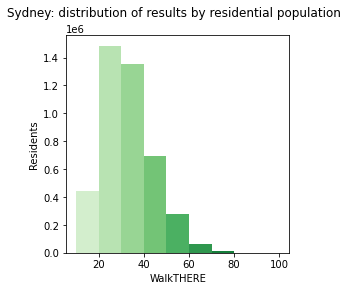

In [32]:
cm = plt.cm.Greens
bins=[10,20,30,40,50,60,70,80,90,100]
fig, ax1 = plt.subplots(nrows=1, ncols=1, sharey=True, figsize=(12, 4))
fig.set_figwidth(4)
ax1.set_xlabel('WalkTHERE')
ax1.set_ylabel('Residents')
fig.suptitle('Sydney: distribution of results by residential population')

n, bins, patches = plt.hist(meshblocks_w['THERE_Index'], weights = meshblocks_w['Person'], label='WalkTHERE',bins=bins)
for i, p in enumerate(patches):
    plt.setp(p, 'facecolor', cm(i/10 + 0.2)) # notice the i/25
    
plt.show()

In [33]:
meshblocks_w.to_file((folder + "Sydney Data\\Sydney MB results walk 181022.gpkg"))

C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\io\file.py:362: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  pd.Int64Index,
C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\io\file.py:389: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(gdal_version) >= LooseVersion("3.0.0") and crs:


In [34]:
small_w_results.to_file((folder + "Sydney Data\\Sydney full results walk 181022.gpkg"))

C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\io\file.py:389: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(gdal_version) >= LooseVersion("3.0.0") and crs:


### Visualise results

In [32]:
import_results = gpd.read_file(folder + "Sydney Data\\Sydney MB results walk 190722.gpkg")

In [35]:
envelope = small_w_results.to_crs("EPSG:4326").unary_union.envelope
envelope = gpd.GeoDataFrame({'geometry': envelope, 'convex_hull':[1]},crs=proj_crs)
graph_envelope = gpd.GeoDataFrame({'geometry': small_w_results.to_crs("EPSG:4326").unary_union.envelope, 'convex_hull':[1]},crs="EPSG:4326")

In [36]:
Sydney_mbs = meshblocks_w.clip(envelope)

In [37]:
Australia = gpd.read_file("C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Data\\ABS Data\\2016_GCCSA_aust_shape\\GCCSA_2016_AUST.shp").to_crs(proj_crs)
Sydney = Australia.clip(envelope)
graph_Sydney = Australia.to_crs("EPSG:4326")
graph_Sydney = graph_Sydney.clip(graph_envelope)

In [41]:
import matplotlib_scalebar 
from matplotlib_scalebar.scalebar import ScaleBar
from shapely.geometry import Point

In [40]:
# uses every third row to speed up plotting. The maps are still considerably over-plotted, for large cities at this figure size.
# 
graph_data = small_w_results.iloc[::3, :].to_crs("EPSG:4326")

points = gpd.GeoSeries([Point(150, -33.8), Point(151, -33.8)], crs=4326)  # Geographic WGS 84 - degrees
points = points.to_crs(32619) # Projected WGS 84 - meters
distance_meters = points[0].distance(points[1])

C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\plotting.py:74: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if mpl >= LooseVersion("3.4") or (mpl > LooseVersion("3.3.2") and "+" in mpl):
C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\setuptools\_distutils\version.py:351: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)
C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\plotting.py:74: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if mpl >= LooseVersion("3.4") or (mpl > LooseVersion("3.3.2") and "+" in mpl):
C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\setuptools\_distutils\version.py:351: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)
C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopanda

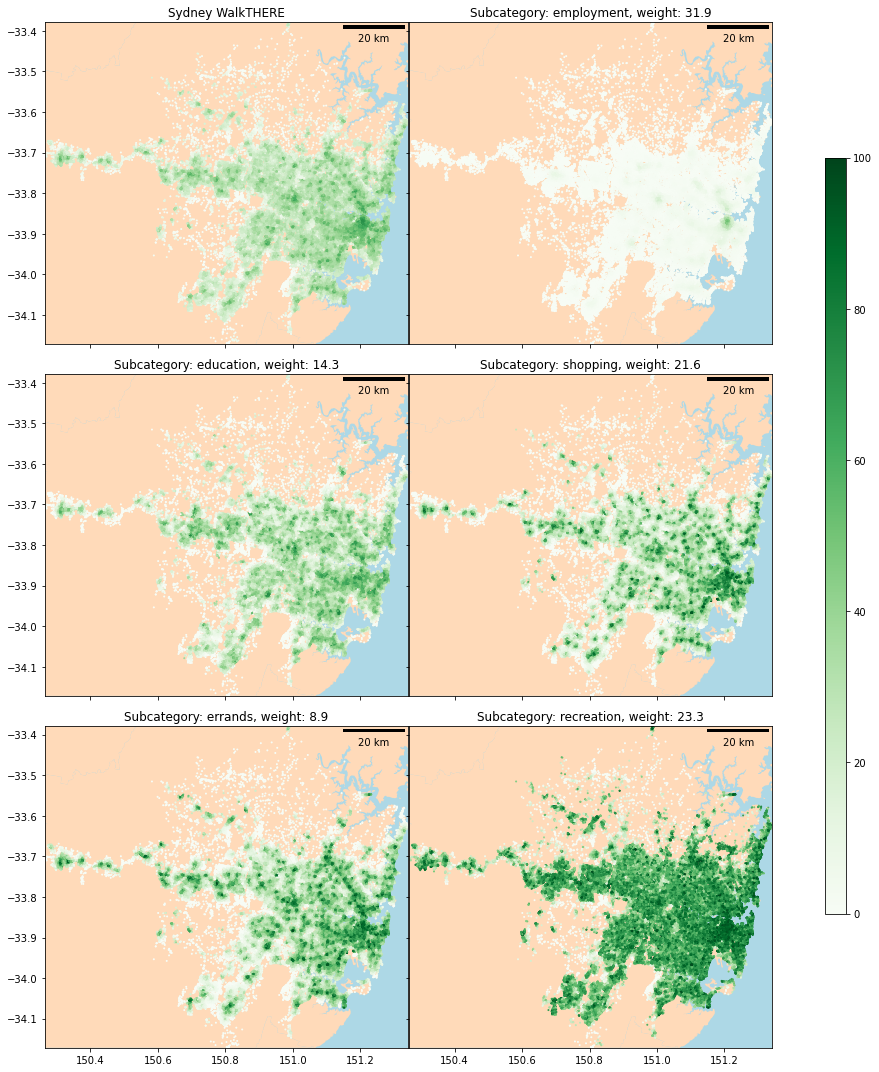

In [42]:
fig, axs = plt.subplots(3,2, sharex=True, sharey=True, 
                       subplot_kw=dict(facecolor="lightblue",xmargin=0,ymargin=0), 
                       figsize=(12,15))

#for ticker, ax in zip(tickers, axs.ravel()):
for ax in axs.ravel():
    graph_Sydney.plot(ax = ax, zorder=1, color='peachpuff')
    ax.add_artist(ScaleBar(distance_meters, frameon=False))

# put overall index in the first subplot
graph_data.plot(ax = axs[0,0], zorder=2, column= "THERE_Index", 
                     cmap='Greens', markersize=1, vmin=0, vmax=100)
axs[0,0].set_title("Sydney WalkTHERE")

for cat in zip(range(0,len(poi_weights)),poi_weights.items()):
    i = cat[0] + 1 # to skip the first subplot
    ax = axs[i//2,i%2]
    graph_data.plot(ax = ax, zorder=2,
                    column = (cat[1][0] + "_" + str(cat[1][1])),
                    cmap='Greens', markersize=1, vmin=0, vmax = cat[1][1])
    ax.set_title("Subcategory: "+cat[1][0]+", weight: "+str(cat[1][1]))
    
plt.tight_layout()

# Create colorbar scale
sm = plt.cm.ScalarMappable(cmap='Greens', norm=plt.Normalize(vmin=0, vmax=100))
 # empty array for the data range
sm._A = []
# add the colorbar to the figure
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.95,0.15,0.025,0.7])
fig.colorbar(sm, cax=cbar_ax)